# EfficientNet-B0 with Entropy Filtering, Ordinal Loss, Focal Loss, and LIME Explanations

This notebook trains an EfficientNet-B0 model combining:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
- **Focal loss**: Focuses on hard examples and handles class imbalance

The combination addresses multiple challenges:
1. Ordinal structure ensures predictions respect grade ordering
2. Focal loss down-weights easy examples and focuses on hard misclassifications
3. Entropy filtering removes noisy/ambiguous samples

In [1]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
import sys
sys.path.append('..')
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi, decode_ordinal_predictions

## Configuration

In [2]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths (this notebook lives in pos-propose/, so repo root is one level up)
ROOT_DIR = '..'
data_dir = '../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths (local to pos-propose/)
os.makedirs('logs', exist_ok=True)
os.makedirs('models', exist_ok=True)

# Pre-trained B0 weights live under code/tests/baseline/models/
model_path = os.path.join(ROOT_DIR, 'code/tests/baseline/models/b0-entropy-ordinal-focal.pth')
log_path = 'logs/b0-entropy-ordinal-focal.txt'

Using device: cuda


## Load Data with Entropy Filtering

In [3]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
Filtered records: 8844

Train: 7073 samples
Validation: 1767 samples
Test: 1590 samples

Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Data Augmentation

In [4]:
val_transforms = None

## Create Datasets and DataLoaders

In [5]:
# Create datasets
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)
print(f"Test batches: {len(test_loader)}")

Test batches: 530


## Model Setup

In [6]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6


## Load Pre-trained Model Weights

In [7]:
# Load weights from the trained model
try:
    # Try importing strict weight loading
    try:
        model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
    except TypeError:
        # Fallback for older torch versions
        model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Pre-trained model loaded successfully from {model_path}!")
except Exception as e:
    print(f"Could not load weights: {e}")

Pre-trained model loaded successfully from ../code/tests/baseline/models/b0-entropy-ordinal-focal.pth!


## Local Interpretable Model-agnostic Explanations (LIME)\n\nEsta seção inclui visualizações LIME adaptando os limiares de classificação (Ordinal Regression) para um formato multiclasse puro para uso no Explicador.

In [8]:
# !pip install -q lime
import lime
from lime import lime_image
from skimage.segmentation import mark_boundaries, slic
import matplotlib.pyplot as plt
import matplotlib.cm as cm

explainer = lime_image.LimeImageExplainer()

def slic_segmentation(image):
    """
    SLIC segmentation tuned for histopathology: smaller, compact superpixels
    that respect tissue structure better than QuickShift default.
    """
    return slic(
        image,
        n_segments=80,
        compactness=15,
        sigma=1.0,
        start_label=0,
        channel_axis=-1
    )


In [9]:
def predict_proba_ordinal_lime(images):
    """
    Wrapper function for LIME.
    Takes a numpy array of images (N, H, W, C), converts them to Tensor (N, C, H, W)
    in a fully vectorized way, feeds them to the model ON THE GPU, and extracts probabilities.
    """
    model.eval()
    
    # Fast vectorized numpy to torch conversion on GPU
    images_chw = np.transpose(images, (0, 3, 1, 2))
    
    # Send entire batch to GPU directly
    batch_tensor = torch.tensor(images_chw, dtype=torch.float32, device=device)
    
    with torch.no_grad():
        logits = model(batch_tensor)
        probs = torch.sigmoid(logits)
        
    N = probs.shape[0]
    
    # Perform mathematical conversions on the GPU
    class_probs = torch.zeros((N, 6), dtype=torch.float32, device=device)
    
    class_probs[:, 0] = 1.0 - probs[:, 0]
    class_probs[:, 1] = probs[:, 0] - probs[:, 1]
    class_probs[:, 2] = probs[:, 1] - probs[:, 2]
    class_probs[:, 3] = probs[:, 2] - probs[:, 3]
    class_probs[:, 4] = probs[:, 3] - probs[:, 4]
    class_probs[:, 5] = probs[:, 4]
    
    class_probs = torch.clamp(class_probs, 0.0, 1.0)
    row_sums = class_probs.sum(dim=1, keepdim=True)
    row_sums[row_sums == 0] = 1e-6
    class_probs = class_probs / row_sums
    
    # Move back to CPU only at the very end
    return class_probs.cpu().numpy()

In [ ]:
from PIL import Image
import os

# Select an image from the test set
sample_idx = 351 # indice otimo acertou classe 5 == 57 erro severo = 351
image_id = test_dataset.dataframe.iloc[sample_idx]['image_id'].strip()
img_path = f"{images_dir}/{image_id}.png"

print(f"LIME Explaining image: {image_id}.png")

# Use skimage to load it exactly like PandasDataset
original_img = test_dataset.__getitem__(sample_idx)[0].numpy()
original_img_np = np.transpose(original_img, (1, 2, 0)).astype(np.uint8)

# Ground truth
grade_gt = int(test_dataset.dataframe.iloc[sample_idx]['isup_grade'])
print(f"Ground Truth ISUP Grade: {grade_gt}")

# Model prediction
model.eval()
with torch.no_grad():
    sample_tensor = test_dataset.__getitem__(sample_idx)[0].unsqueeze(0).to(device)
    logit = model(sample_tensor)
    pred_grade = decode_ordinal_predictions(logit)[0].item()
    print(f"Predicted ISUP Grade: {pred_grade}")

LIME Explaining image: 0c86d570723c4f38b59a5e9678887eac.png
Ground Truth ISUP Grade: 0
Predicted ISUP Grade: 0


In [15]:
import torch
import torch.nn.functional as F
import numpy as np
import cv2
import matplotlib.pyplot as plt


class OrdinalGradCAM:
    """
    Grad-CAM para EfficientNet com cabeça de regressão ordinal.

    Melhorias em relação à versão anterior:
    - Alvo: features[-2] (último bloco MBConv) em vez do último Conv2d do modelo
      inteiro. O bloco MBConv produz gradientes espaciais mais ricos do que a
      conv 1×1 de expansão que vem depois (features[-1]).
    - Score: log(P(classe=predicted_grade)) derivado das probabilidades ordinais,
      em vez de somar logits brutos. Isso foca o gradiente na classe predita.
    - Hook de gradiente registrado no tensor de saída (output.register_hook),
      mais confiável do que register_full_backward_hook em containers Sequential.
    - Normalização por percentil (p2/p98) em vez de min-max, para suprimir
      ativações outlier que colapsariam o contraste nas regiões relevantes.
    """

    def __init__(self, model):
        self.model = model
        self.feature_maps = None
        self.gradient = None
        self._hook_handle = None

        # Alvo explícito: último bloco MBConv de EfficientNet
        target_layer = None
        try:
            target_layer = model.model.features[-2]
            print(f"Grad-CAM target: model.model.features[-2]  ({type(target_layer).__name__})")
        except AttributeError:
            pass

        if target_layer is None:
            # Fallback: último Conv2d encontrado por DFS
            for name, module in model.named_modules():
                if isinstance(module, torch.nn.Conv2d):
                    target_layer = module
                    print(f"Fallback Grad-CAM target: {name}")

        def _forward_hook(module, inp, output):
            self.feature_maps = output
            # Registra hook de gradiente diretamente no tensor de saída.
            # Só funciona quando gradientes estão habilitados.
            if output.requires_grad:
                output.register_hook(lambda g: setattr(self, "gradient", g))

        self._hook_handle = target_layer.register_forward_hook(_forward_hook)

    def __call__(self, x, predicted_grade):
        self.model.eval()
        self.feature_maps = None
        self.gradient = None

        # Forward pass com gradientes ativos para o hook de tensor funcionar
        logits = self.model(x)
        probs = torch.sigmoid(logits)   # (1, 5) limiares ordinais

        # Converte saídas ordinais em probabilidades por classe:
        #   P(grade=0) = 1 - σ(l0)
        #   P(grade=k) = σ(l_{k-1}) - σ(l_k)   para k = 1..4
        #   P(grade=5) = σ(l4)
        n = probs.shape[1]
        class_probs = torch.empty(n + 1, device=logits.device)
        class_probs[0] = 1.0 - probs[0, 0]
        for i in range(1, n):
            class_probs[i] = probs[0, i - 1] - probs[0, i]
        class_probs[n] = probs[0, n - 1]
        class_probs = class_probs.clamp(1e-7, 1.0)

        # Log-probabilidade: gradientes mais localizados do que soma de logits brutos
        score = torch.log(class_probs[predicted_grade])

        self.model.zero_grad()
        score.backward()

        if self.gradient is None or self.feature_maps is None:
            raise RuntimeError(
                "Hooks não capturaram dados. Garanta que torch.grad_enabled(True) "
                "está ativo antes de chamar este método."
            )

        # Grad-CAM: peso de cada canal = média espacial do seu gradiente
        weights = self.gradient.detach().mean(dim=(2, 3), keepdim=True)   # (1, C, 1, 1)
        cam = F.relu((weights * self.feature_maps.detach()).sum(dim=1))    # (H, W)

        cam_np = cam.squeeze().cpu().numpy()

        # Normalização por percentil — robusto contra outliers de ativação
        lo, hi = np.percentile(cam_np, [2, 98])
        cam_np = np.clip((cam_np - lo) / (hi - lo + 1e-8), 0.0, 1.0)

        return cam_np

    def remove_hook(self):
        if self._hook_handle is not None:
            self._hook_handle.remove()


Grad-CAM target: model.model.features[-2]  (Sequential)
Ground Truth: 5  |  Predicted: 5


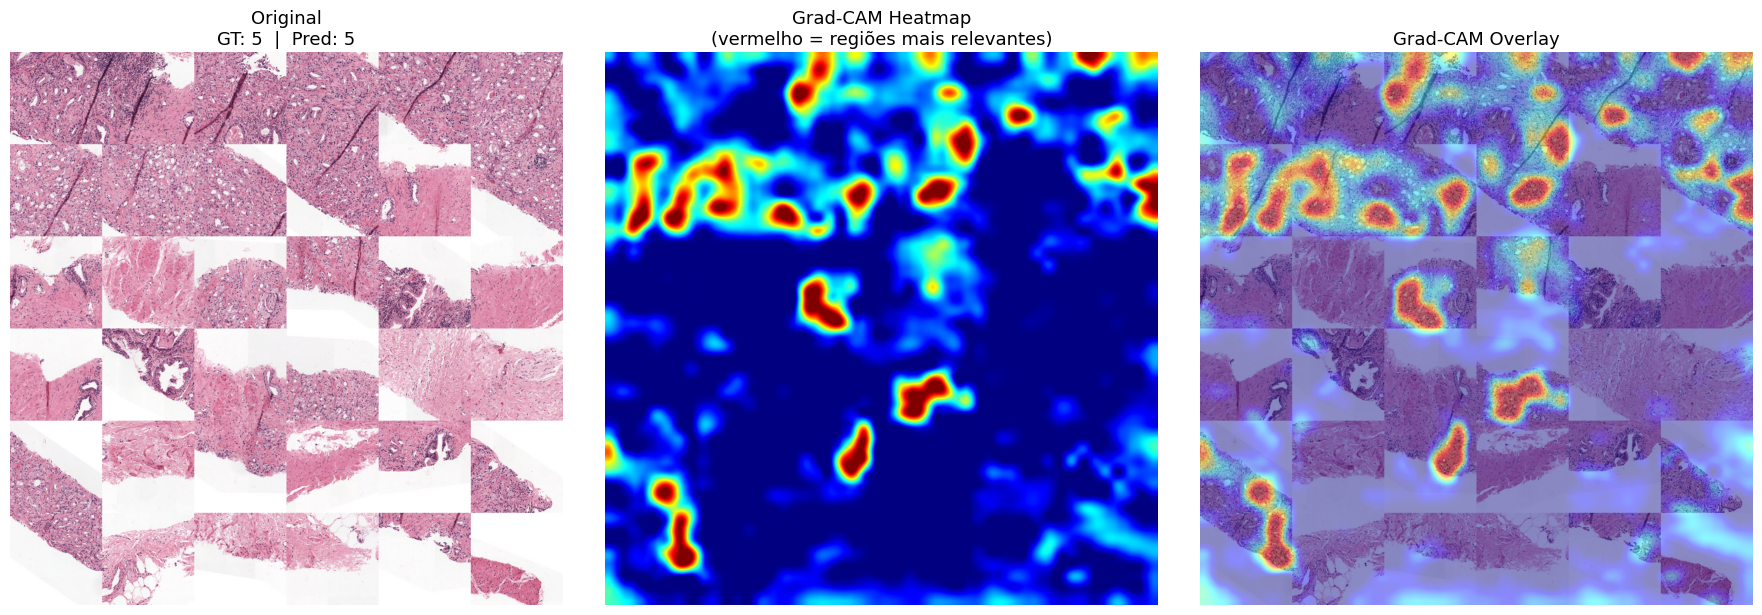

In [16]:
# Instancia o Grad-CAM (hooks são registrados aqui)
grad_cam = OrdinalGradCAM(model)

# --- Predição sem alterar o estado de gradientes ---
model.eval()
with torch.no_grad():
    logit = model(sample_tensor)
    pred_grade = decode_ordinal_predictions(logit)[0].item()

print(f"Ground Truth: {grade_gt}  |  Predicted: {pred_grade}")

# --- Gera o heatmap (requer gradientes ativos) ---
# O hook de tensor só captura gradiente quando requires_grad=True no tensor de saída,
# por isso é necessário habilitar grad antes de chamar grad_cam.
torch.set_grad_enabled(True)
cam_mask = grad_cam(sample_tensor, pred_grade)
torch.set_grad_enabled(False)

# --- Prepara imagem para exibição ---
original_img = test_dataset.__getitem__(sample_idx)[0].numpy()
original_img_np = np.transpose(original_img, (1, 2, 0)).astype(np.uint8)

H, W = original_img_np.shape[:2]

# Upsampling bicúbico: bordas mais suaves do que o linear padrão
cam_resized = cv2.resize(cam_mask, (W, H), interpolation=cv2.INTER_CUBIC)
cam_resized = np.clip(cam_resized, 0.0, 1.0)

heatmap_bgr = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap_rgb = cv2.cvtColor(heatmap_bgr, cv2.COLOR_BGR2RGB)

# Alpha-blend: 55% original + 45% heatmap mantém detalhes do tecido visíveis
alpha = 0.55
overlay = np.clip(
    original_img_np.astype(np.float32) * alpha + heatmap_rgb.astype(np.float32) * (1 - alpha),
    0, 255
).astype(np.uint8)

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_img_np)
axes[0].set_title(f"Original\nGT: {grade_gt}  |  Pred: {pred_grade}", fontsize=13)
axes[0].axis("off")

axes[1].imshow(heatmap_rgb)
axes[1].set_title("Grad-CAM Heatmap\n(vermelho = regiões mais relevantes)", fontsize=13)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Grad-CAM Overlay", fontsize=13)
axes[2].axis("off")

plt.tight_layout()
os.makedirs("logs", exist_ok=True)
plt.savefig("logs/gradcam_entropy_ordinal_focal.png", dpi=300, bbox_inches="tight")
plt.show()

# Remove hooks para evitar acumulação em re-execuções
grad_cam.remove_hook()
